# Notebook 02 — GEMIS Model Training Tutorial

A step-by-step walkthrough of the GEMIS pipeline:
1. Load MixATIS data and extend the BART vocabulary
2. Inspect the structured target sequence format (`<intent:X> start end <slot:Z> ...`)
3. Verify the `pointer_targets` alignment
4. Instantiate the full GEMIS model (BART + AoA decoder + Pointer Network)
5. Run a forward pass and inspect logits shape
6. Train for 10 steps and verify the loss decreases
7. Greedy generation + metric computation

In [1]:
import os, sys
os.environ['USE_TF'] = '0'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import torch
from pathlib import Path
from transformers import BartTokenizerFast

from gemis.data.collator import GEMISDataCollator
from gemis.data.dataset import GEMISDataset, bio_to_spans, build_target_tokens
from gemis.data.tokenizer import extend_tokenizer_vocab
from gemis.models.aoa import AoACrossAttention
from gemis.models.bart_layer import GEMISDecoderLayer
from gemis.models.gemis import GEMISModel
from gemis.training.metrics import compute_metrics, parse_target_sequence
from gemis.utils.io import load_raw_dataset
from gemis.utils.training_utils import collect_labels

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 1. Data & Tokenizer

In [2]:
TRAIN = Path('../data/raw/mixatis/train.txt')
DEV   = Path('../data/raw/mixatis/dev.txt')
assert TRAIN.exists(), 'Run: python scripts/download_data.py --dataset mixatis'

intent_labels, slot_labels = collect_labels([
    Path('../data/raw/mixatis/train.txt'),
    Path('../data/raw/mixatis/dev.txt'),
    Path('../data/raw/mixatis/test.txt'),
])
print(f'{len(intent_labels)} intent labels, {len(slot_labels)} slot types')
print('Intents:', intent_labels)

18 intent labels, 78 slot types
Intents: ['atis_abbreviation', 'atis_aircraft', 'atis_airfare', 'atis_airline', 'atis_airport', 'atis_capacity', 'atis_cheapest', 'atis_city', 'atis_day_name', 'atis_distance', 'atis_flight', 'atis_flight_no', 'atis_flight_time', 'atis_ground_fare', 'atis_ground_service', 'atis_meal', 'atis_quantity', 'atis_restriction']


In [3]:
tokenizer = BartTokenizerFast.from_pretrained('facebook/bart-base')
print('Vocab before extension:', len(tokenizer))

extend_tokenizer_vocab(tokenizer, intent_labels, slot_labels)
print('Vocab after  extension:', len(tokenizer))

Vocab before extension: 50265
Vocab after  extension: 50361


## 2. Target Sequence Inspection

In [4]:
raw = load_raw_dataset(TRAIN)
# Find a 2-intent sample for demonstration
s2 = next(s for s in raw if len(s.intents) == 2)

words = [t.word for t in s2.tokens]
bio   = [t.bio_tag for t in s2.tokens]
spans = bio_to_spans(words, bio)

print('Utterance:', ' '.join(words))
print('Intents  :', s2.intents)
print('Spans    :')
for sp in spans:
    print(f'  words[{sp.start}:{sp.end}]  {sp.slot_type:35s} → "{" ".join(words[sp.start:sp.end])}"')
print()

target_ids = build_target_tokens(s2.intents, spans, tokenizer)
target_str = tokenizer.decode(target_ids, skip_special_tokens=False)
print('Target IDs :', target_ids)
print('Target text:', target_str)

Utterance: how many seats in a 100 and also which cities are serviced by both american and delta airlines
Intents  : ['atis_capacity', 'atis_city']
Spans    :
  words[5:6]  aircraft_code                       → "100"
  words[14:15]  airline_name                        → "american"
  words[16:18]  airline_name                        → "delta airlines"

Target IDs : [0, 50270, 50272, 195, 231, 50283, 501, 379, 50285, 545, 504, 50285, 2]
Target text: <s><intent:atis_capacity><intent:atis_city> 5 6<slot:aircraft_code> 14 15<slot:airline_name> 16 18<slot:airline_name></s>


In [5]:
# Round-trip check via parse_target_sequence
frame = parse_target_sequence(target_ids[1:], tokenizer)  # skip BOS
print('Parsed frame:')
print('  intents:', set(frame.intents))
print('  spans  :', frame.slot_spans)

expected_intents = frozenset(s2.intents)
expected_spans   = [(sp.start, sp.end, sp.slot_type) for sp in spans]
print('\nIntent match:', frame.intents == expected_intents)
print('Slot match  :', set(frame.slot_spans) == set(expected_spans))

Parsed frame:
  intents: {'atis_city', 'atis_capacity'}
  spans  : [(5, 6, 'aircraft_code'), (14, 15, 'airline_name'), (16, 18, 'airline_name')]

Intent match: True
Slot match  : True


## 3. Dataset & DataLoader

In [6]:
from torch.utils.data import DataLoader

train_ds = GEMISDataset(TRAIN, tokenizer, max_source_length=128, max_target_length=64)
dev_ds   = GEMISDataset(DEV,   tokenizer, max_source_length=128, max_target_length=64)
collator = GEMISDataCollator(tokenizer=tokenizer)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  collate_fn=collator)
dev_loader   = DataLoader(dev_ds,   batch_size=4, shuffle=False, collate_fn=collator)

batch = next(iter(train_loader))
print('input_ids        :', batch['input_ids'].shape)
print('labels           :', batch['labels'].shape)
print('decoder_input_ids:', batch['decoder_input_ids'].shape)
print('pointer_targets  :', batch['pointer_targets'].shape)

n_ptr = (batch['pointer_targets'] >= 0).sum().item()
print(f'\nPointer steps in batch: {n_ptr} / {batch["pointer_targets"].numel()}')

input_ids        : torch.Size([4, 40])
labels           : torch.Size([4, 25])
decoder_input_ids: torch.Size([4, 25])
pointer_targets  : torch.Size([4, 25])

Pointer steps in batch: 32 / 100


## 4. Instantiate GEMIS

> Requires `facebook/bart-base` (~560 MB). First run downloads it automatically.

In [7]:
print('Loading GEMIS model...')
model = GEMISModel(
    backbone_name='facebook/bart-base',
    intent_labels=intent_labels,
    slot_labels=slot_labels,
    tokenizer=tokenizer,
    mlp_hidden=512,
)
model.to(device)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_trainable:,}')

# Verify AoA injection
decoder  = model.bart.model.decoder
aoa_ok   = all(isinstance(layer, GEMISDecoderLayer) for layer in decoder.layers)
enc_ok   = all(isinstance(layer.encoder_attn, AoACrossAttention) for layer in decoder.layers)
eager_ok = all(
    getattr(getattr(layer.self_attn, 'config', None), '_attn_implementation', None) == 'eager'
    for layer in decoder.layers
)
print(f'GEMISDecoderLayer injected : {aoa_ok}  ✓')
print(f'AoACrossAttention injected : {enc_ok}  ✓')
print(f'Self-attn forced to eager  : {eager_ok} ✓  (required for SAM weights)')

Loading GEMIS model...


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Trainable parameters: 179,548,929
GEMISDecoderLayer injected : True  ✓
AoACrossAttention injected : True  ✓
Self-attn forced to eager  : True ✓  (required for SAM weights)


## 5. Forward Pass — Logit Inspection

In [8]:
model.eval()
batch_dev = {k: v.to(device) for k, v in batch.items()}

with torch.no_grad():
    out = model(
        input_ids         = batch_dev['input_ids'],
        attention_mask    = batch_dev['attention_mask'],
        decoder_input_ids = batch_dev['decoder_input_ids'],
        labels            = batch_dev['labels'],
        pointer_targets   = batch_dev['pointer_targets'],
    )

B, T, NL = out['logits'].shape
N = batch_dev['input_ids'].shape[1]
L = len(tokenizer)
print(f'Logits shape : {B} × {T} × {NL}')
print(f'  = {N} encoder positions  +  {L} vocab tokens  =  {N + L}')
print(f'Loss (random weights)       : {out["loss"].item():.4f}')

argmax   = out['logits'].argmax(dim=-1)
ptr_frac = (argmax < N).float().mean().item()
print(f'Fraction of pointer predictions (untrained): {ptr_frac:.2%}')

Logits shape : 4 × 25 × 50401
  = 40 encoder positions  +  50361 vocab tokens  =  50401
Loss (random weights)       : 11.5248
Fraction of pointer predictions (untrained): 0.00%


## 6. Mini Training Loop (10 steps)

Step  1/10  loss: 11.6993
Step  2/10  loss: 10.1732
Step  3/10  loss: 9.3462
Step  4/10  loss: 8.8582
Step  5/10  loss: 8.8129
Step  6/10  loss: 8.4960
Step  7/10  loss: 7.9845
Step  8/10  loss: 7.7337
Step  9/10  loss: 7.2377
Step 10/10  loss: 7.3325


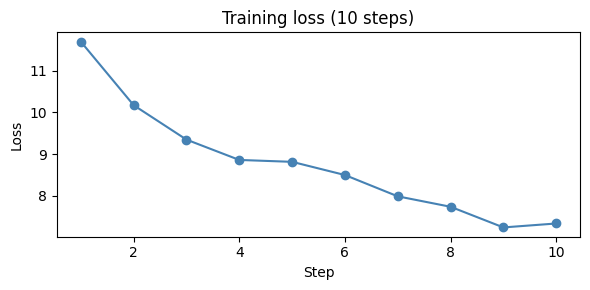


Loss: 11.6993 → 7.3325


In [9]:
import matplotlib.pyplot as plt
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)
model.train()
losses = []

for step, b_step in enumerate(train_loader):
    if step >= 10:
        break
    b = {k: v.to(device) for k, v in b_step.items()}
    optimizer.zero_grad()
    out = model(
        input_ids         = b['input_ids'],
        attention_mask    = b['attention_mask'],
        decoder_input_ids = b['decoder_input_ids'],
        labels            = b['labels'],
        pointer_targets   = b['pointer_targets'],
    )
    out['loss'].backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    losses.append(out['loss'].item())
    print(f'Step {step + 1:2d}/10  loss: {out["loss"].item():.4f}')

plt.figure(figsize=(6, 3))
plt.plot(range(1, len(losses) + 1), losses, marker='o', color='steelblue')
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Training loss (10 steps)')
plt.tight_layout(); plt.show()
print(f'\nLoss: {losses[0]:.4f} → {losses[-1]:.4f}')

## 7. Greedy Generation & Evaluation

In [10]:
model.eval()
eval_batch = next(iter(dev_loader))
eval_b     = {k: v.to(device) for k, v in eval_batch.items()}

with torch.no_grad():
    generated = model.generate(
        input_ids=eval_b['input_ids'],
        attention_mask=eval_b['attention_mask'],
        max_new_tokens=40,
    )

golds, preds = [], []
for i, gen_ids in enumerate(generated):
    gold_ids = [t for t in eval_b['labels'][i].tolist() if t != -100]
    src      = tokenizer.decode(eval_b['input_ids'][i], skip_special_tokens=True)
    gold_str = tokenizer.decode(gold_ids, skip_special_tokens=False)
    pred_str = tokenizer.decode(gen_ids,  skip_special_tokens=False)
    print(f'[{i}] Source: {src[:70]}')
    print(f'     Gold  : {gold_str[:80]}')
    print(f'     Pred  : {pred_str[:80]}')
    print()
    golds.append(parse_target_sequence(gold_ids, tokenizer))
    preds.append(parse_target_sequence(gen_ids,  tokenizer))

metrics = compute_metrics(golds, preds)
print('Metrics (after 10 steps — model not yet trained):')
for k, v in metrics.items():
    print(f'  {k:<22}: {v:.2f}')

[0] Source: how many passengers can a boeing 737 hold and also flights from pittsb
     Gold  : <intent:atis_capacity><intent:atis_flight> 6 7<slot:aircraft_code> 12 13<slot:fr
     Pred  :  Si ended ended ended ended ended ended ended ended ended ended ended ended ende

[1] Source: list the total number of flights to all airports by delta
     Gold  : <intent:atis_quantity> 10 11<slot:airline_name></s>
     Pred  :  serious�������� 6� ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( (

[2] Source: what city is mco , how many first class flights does united have today
     Gold  : <intent:atis_city><intent:atis_quantity><intent:atis_restriction> 3 4<slot:airpo
     Pred  :  serious� ended ( 15 ( ( ( ( ( 15 ( ( ( ( ( ( ( ( 15 ( ( ( ( ( ( ( ( 15 ( ( ( ( 

[3] Source: how long does it take to fly from boston to atlanta and how much is a 
     Gold  : <intent:atis_distance><intent:atis_ground_fare> 8 9<slot:fromloc.city_name> 10 1
     Pred  :  Si ended ( ( ( ( ( ( ( ( ( ( ( 14 ( ( 

## 8. Full Training

To run a full training (30 epochs, batch size 16) from the terminal:

```bash
# MixATIS
./run.sh scripts/train.py --config configs/mixatis.yaml

# MixSNIPS
./run.sh scripts/train.py --config configs/mixsnips.yaml

# Evaluate
./run.sh scripts/evaluate.py --checkpoint checkpoints/mixatis/best.pt --config configs/mixatis.yaml
```

Expected results (paper, BART-large):

| Dataset  | Slot F1 | Intent Acc | Overall Acc |
|----------|---------|------------|-------------|
| MixATIS  | 89.2    | 81.4       | 53.4        |
| MixSNIPS | 97.4    | 98.1       | 87.4        |
| MultiATIS | 95.4   | 94.1       | 71.5        |
| MultiSNIPS | 98.1  | 98.8       | 91.5        |